In [ ]:
!pip install imbalanced-learn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans

from imblearn.over_sampling import SMOTE

import tensorflow as tf

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
file_id = "16sxJNpG_S473cy87uceKC5tkkPqeiAdA"
url = f"https://drive.google.com/uc?id={file_id}&export=download"
df = pd.read_csv(url)
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
print("Dataset Description:")
print(f"\nTotal data points : {df.shape[0]}")
print(f"Total features    : {df.shape[1] - 1}  (excluding target)")
print(f"Target column     : loan_status (0=Rejected, 1=Approved)")

print("\nFeature types:")
print("-" * 40)
for col in df.columns:
    dtype = df[col].dtype
    if dtype == 'object' or str(dtype) == 'str':
        print(f"  {col:40s} → Categorical")
    else:
        print(f"  {col:40s} → Quantitative")

print("\nNull values per column:")
print()
print(df.isnull().sum())

print("\nStatistical summary:")
df.describe()

Dataset Description:

Total data points : 45000
Total features    : 13  (excluding target)
Target column     : loan_status (0=Rejected, 1=Approved)

Feature types:
----------------------------------------
  person_age                               → Quantitative
  person_gender                            → Categorical
  person_education                         → Categorical
  person_income                            → Quantitative
  person_emp_exp                           → Quantitative
  person_home_ownership                    → Categorical
  loan_amnt                                → Quantitative
  loan_intent                              → Categorical
  loan_int_rate                            → Quantitative
  loan_percent_income                      → Quantitative
  cb_person_cred_hist_length               → Quantitative
  credit_score                             → Quantitative
  previous_loan_defaults_on_file           → Categorical
  loan_status                              → Q

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


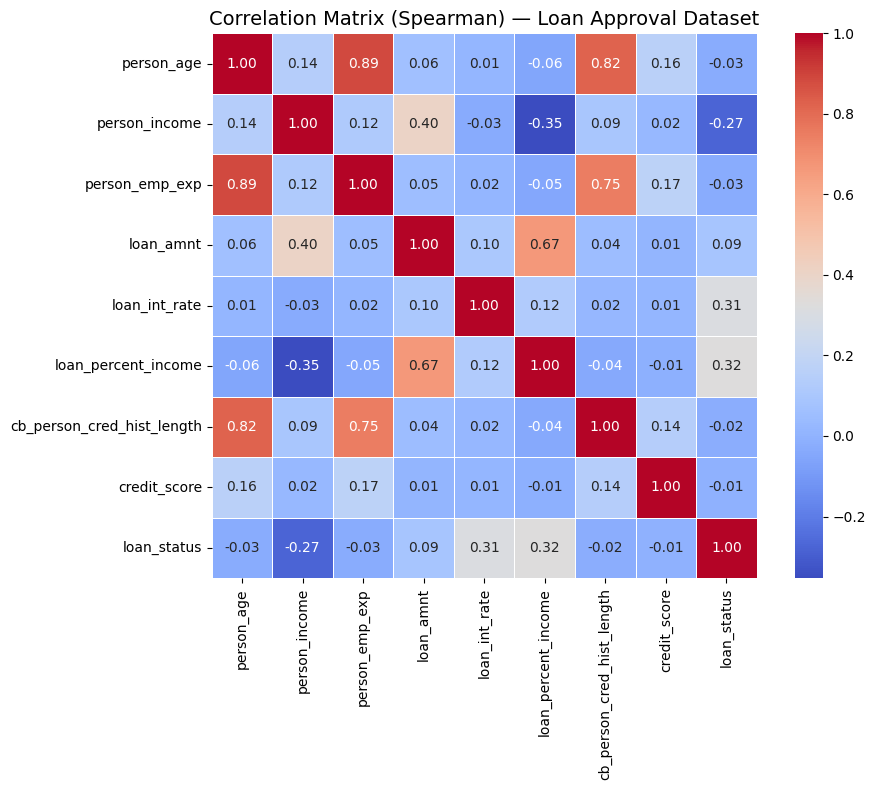

In [ ]:
numeric_cols = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score',
    'loan_status'  # target variable
]

numeric_df = df[numeric_cols]
numeric_df = numeric_df.dropna()
corr_matrix = numeric_df.corr(method='spearman')

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix (Spearman) — Loan Approval Dataset", fontsize=14)
plt.tight_layout()
plt.show()

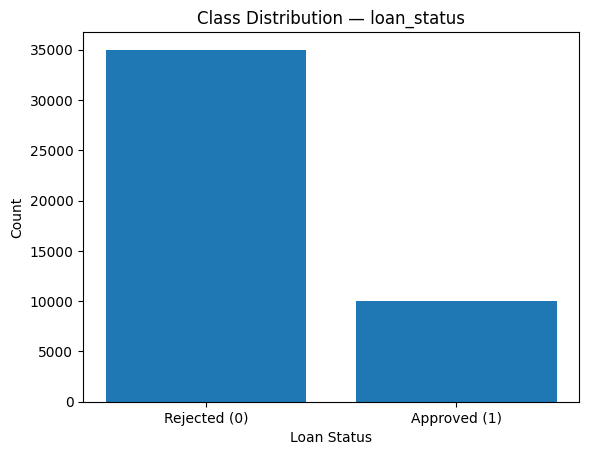

In [ ]:
class_counts = df['loan_status'].value_counts().sort_index()
plt.bar(['Rejected (0)', 'Approved (1)'], class_counts.values)
plt.title('Class Distribution — loan_status')
plt.ylabel('Count')
plt.xlabel('Loan Status')
plt.show()

In [ ]:
print(class_counts / len(df) * 100)

loan_status
0    77.777778
1    22.222222
Name: count, dtype: float64


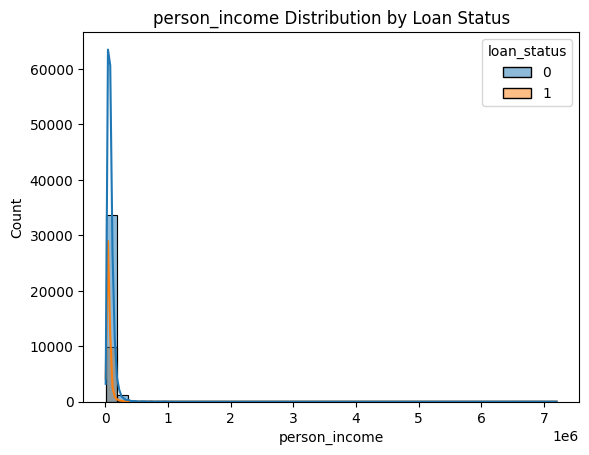

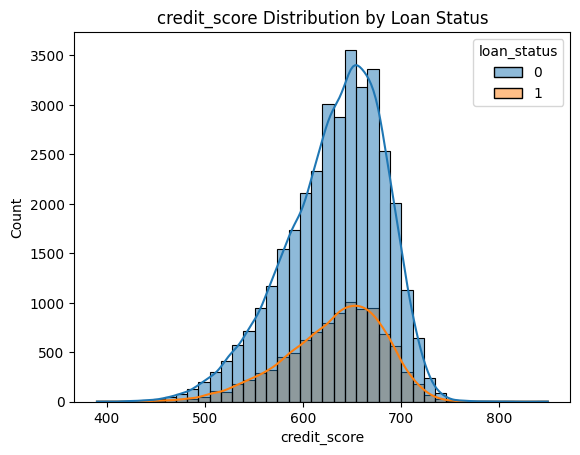

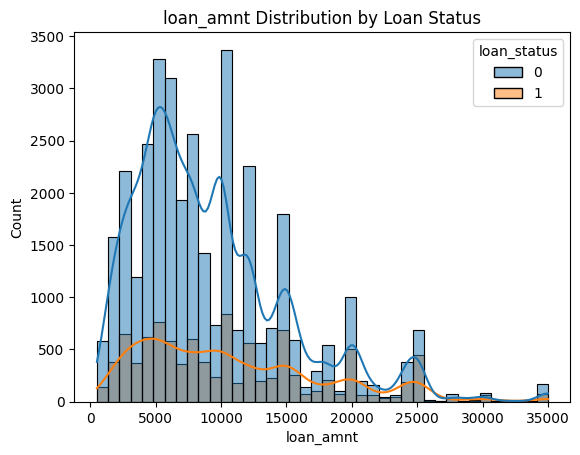

In [ ]:
import seaborn as sns

key_numeric = ['person_income', 'credit_score', 'loan_amnt']

for col in key_numeric:
    sns.histplot(data=df, x=col, hue='loan_status', bins=40, kde=True)
    plt.title(f'{col} Distribution by Loan Status')
    plt.show()

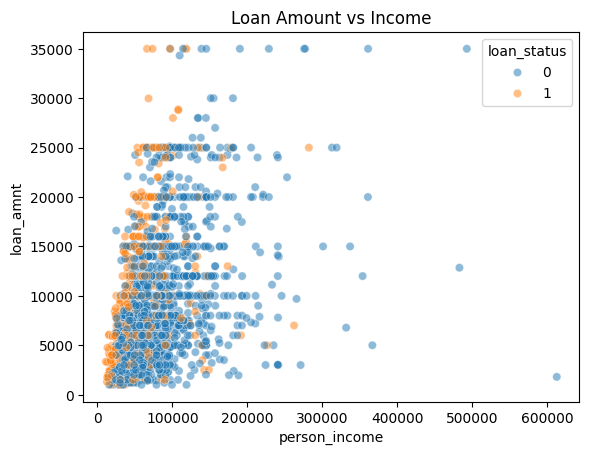

In [ ]:
sample = df.sample(2000, random_state=42)

sns.scatterplot(
    data=sample,
    x='person_income',
    y='loan_amnt',
    hue='loan_status',
    alpha=0.5
)

plt.title('Loan Amount vs Income')
plt.show()

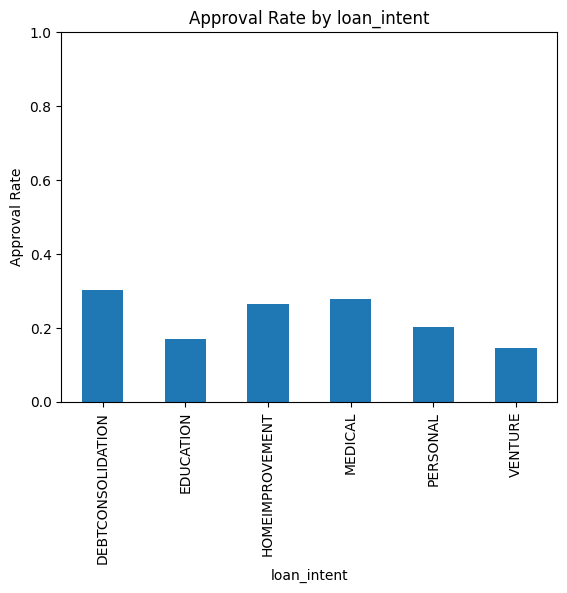

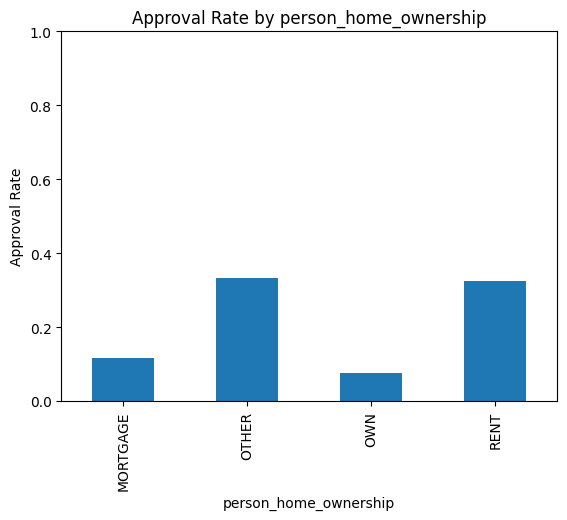

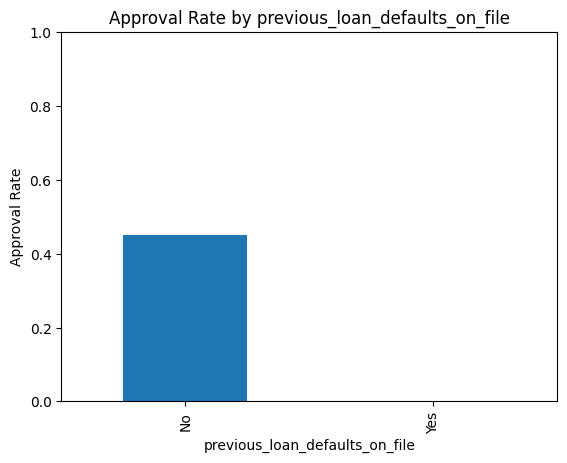

In [ ]:
categoricals = [
    'loan_intent',
    'person_home_ownership',
    'previous_loan_defaults_on_file'
]

for col in categoricals:
    approval_rate = df.groupby(col)['loan_status'].mean()

    approval_rate.plot(kind='bar')
    plt.title(f'Approval Rate by {col}')
    plt.ylabel('Approval Rate')
    plt.ylim(0, 1)
    plt.show()

In [ ]:
df_clean = df.copy()

# Encode binary categorical variables
from sklearn.preprocessing import LabelEncoder, StandardScaler

binary_cols = ['person_gender', 'previous_loan_defaults_on_file']
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# One-hot encode nominal categorical variables
ohe_cols = ['person_education', 'person_home_ownership', 'loan_intent']
df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=True)

# Split features and target
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [ ]:
# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale properly (fit only on training data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [ ]:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"AUC Score : {roc_auc_score(y_test, y_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training Logistic Regression...
Accuracy  : 0.8657
Precision : 0.6382
Recall    : 0.9130
F1 Score  : 0.7513
AUC Score : 0.9562

Confusion Matrix:
[[5965 1035]
 [ 174 1826]]


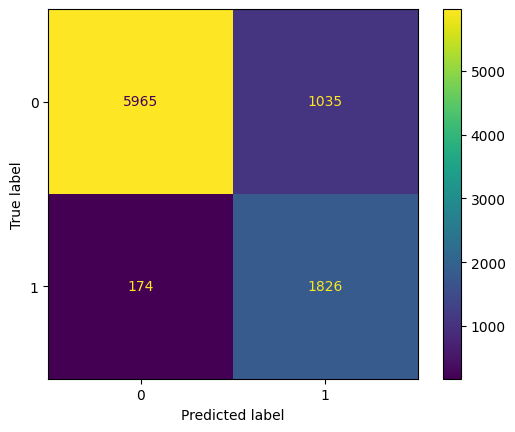

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
print("Training Decision Tree...")

dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train_bal, y_train_bal)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print(f"  Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_dt, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_dt):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_dt):.4f}")
print(f"  AUC Score : {roc_auc_score(y_test, y_prob_dt):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
print("\nConfusion Matrix:")
print(cm)

Training Decision Tree...
  Accuracy  : 0.8793
  Precision : 0.6752
  Recall    : 0.8805
  F1 Score  : 0.7643
  AUC Score : 0.9621

Confusion Matrix:
[[6153  847]
 [ 239 1761]]


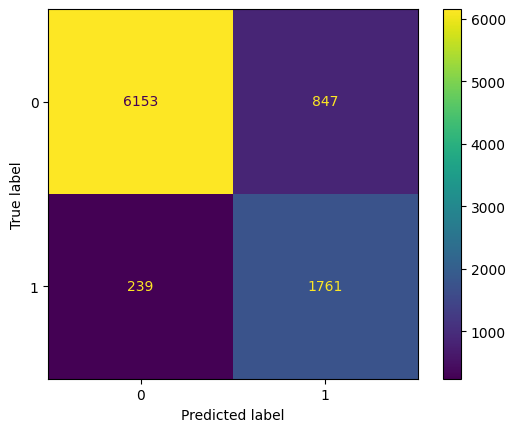

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.show()

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print("Building and training Neural Network...")

# 1. Feature Scaling
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# 2. Define Model
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_bal_scaled.shape[1],)),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

# 3. Compile Model
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

nn_model.summary()

# 4. Train Model
history = nn_model.fit(
    X_train_bal_scaled, y_train_bal,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    verbose=1
)

# 5. Evaluation
y_prob_nn = nn_model.predict(X_test_scaled).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("\nNeural Network Performance:")

print(f"  Accuracy  : {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_nn, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_nn):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_nn):.4f}")
print(f"  AUC Score : {roc_auc_score(y_test, y_prob_nn):.4f}")

# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nn)
print("\nConfusion Matrix:")
print(cm)

Building and training Neural Network...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8393 - loss: 0.3415 - val_accuracy: 0.9482 - val_loss: 0.1875
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8807 - loss: 0.2585 - val_accuracy: 0.9345 - val_loss: 0.1939
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8868 - loss: 0.2461 - val_accuracy: 0.9314 - val_loss: 0.1922
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8909 - loss: 0.2378 - val_accuracy: 0.9277 - val_loss: 0.1874
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8912 - loss: 0.2319 - val_accuracy: 0.9230 - val_loss: 0.1947
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8927 - loss: 0.2275 - val_accuracy: 0.9266 - val_loss: 0.1863
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8947 - loss: 0.2244 - val_accuracy: 0.9273 - val_loss: 0.1897
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8961 - loss: 0.2221 - val_accu

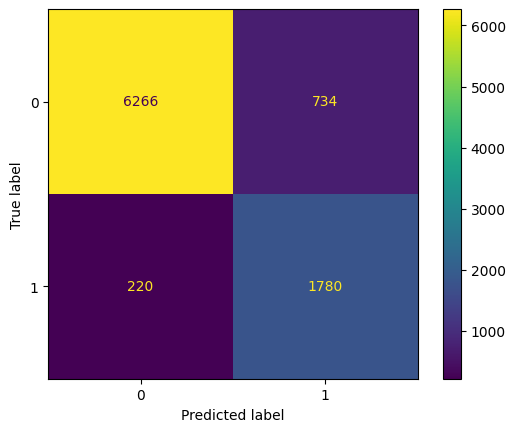

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn)
plt.show()

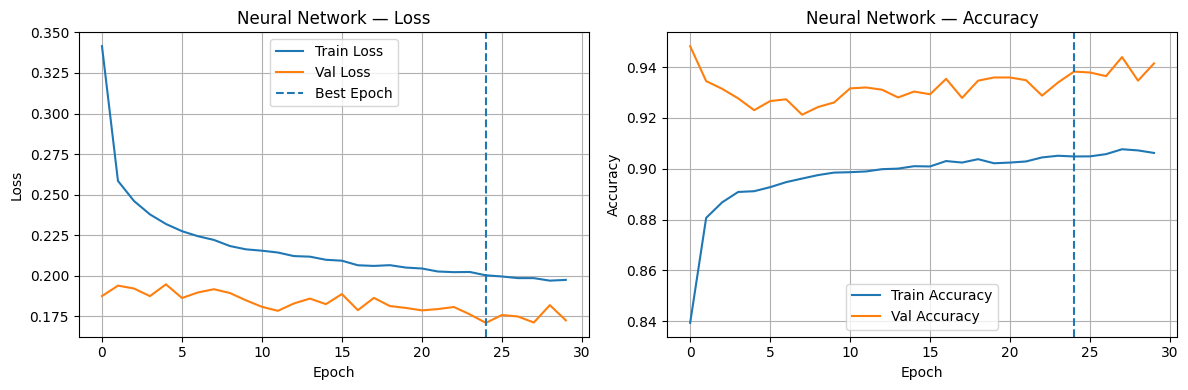

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Neural Network — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Neural Network — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True)

# Mark best epoch
best_epoch = np.argmin(history.history['val_loss'])
axes[0].axvline(best_epoch, linestyle='--', label='Best Epoch')
axes[1].axvline(best_epoch, linestyle='--')

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.savefig('nn_history.png', dpi=150)
plt.show()

Applying KMeans clustering (k=2, matching binary classes)...


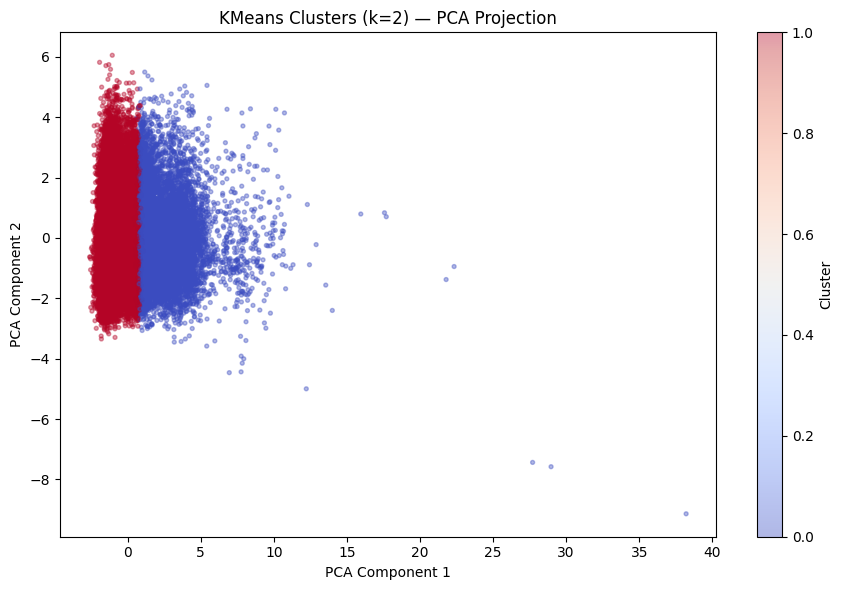

Cluster distribution:
  Cluster 0: 10,931 samples
  Cluster 1: 34,069 samples


In [ ]:
print("Applying KMeans clustering (k=2, matching binary classes)...")

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

X_all_scaled = np.vstack([X_train, X_test])
cluster_labels = kmeans.fit_predict(X_all_scaled)

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels,
                      cmap='coolwarm', alpha=0.4, s=8)
plt.colorbar(scatter, label='Cluster')
plt.title('KMeans Clusters (k=2) — PCA Projection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('kmeans.png', dpi=150)
plt.show()

print("Cluster distribution:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c:,} samples")

In [ ]:
from sklearn.metrics import f1_score
models = ['Logistic Regression', 'Decision Tree', 'Neural Network']

# Metrics
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_nn)
]

precisions = [
    precision_score(y_test, y_pred, zero_division=0),
    precision_score(y_test, y_pred_dt, zero_division=0),
    precision_score(y_test, y_pred_nn, zero_division=0)
]

recalls = [
    recall_score(y_test, y_pred),
    recall_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_nn)
]

f1_scores = [
    f1_score(y_test, y_pred),
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_nn)
]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)

auc_lr = roc_auc_score(y_test, y_prob)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_nn = roc_auc_score(y_test, y_prob_nn)

auc_scores = [auc_lr, auc_dt, auc_nn]

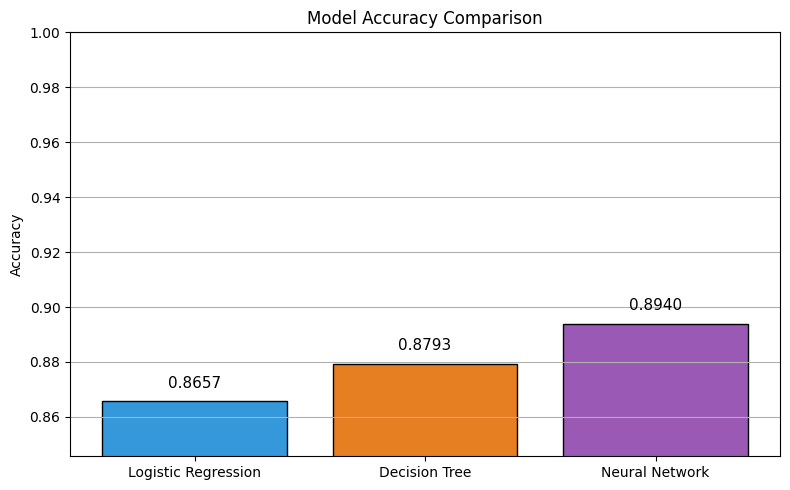

In [ ]:
# Accuracy Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies,
               color=['#3498DB', '#E67E22', '#9B59B6'],
               edgecolor='black')
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=11)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(min(accuracies) - 0.02, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()

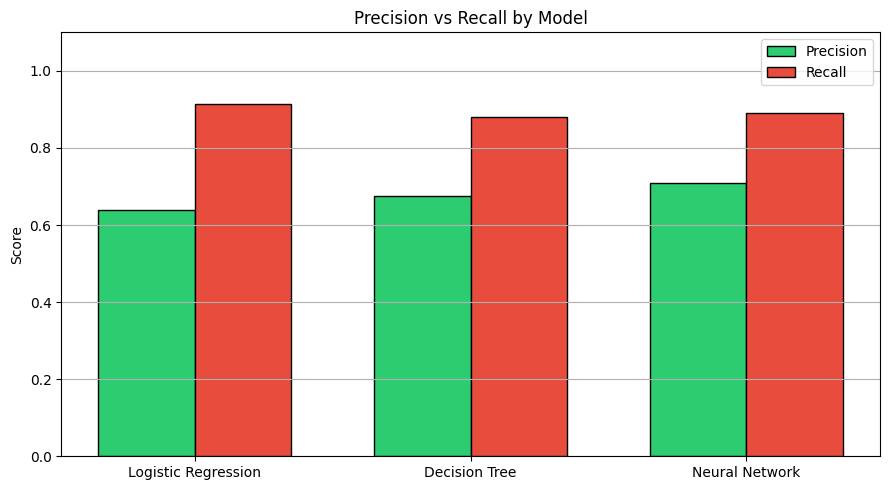

In [ ]:
# Precision vs Recall
x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, precisions, width, label='Precision', color='#2ECC71', edgecolor='black')
ax.bar(x + width/2, recalls,   width, label='Recall',    color='#E74C3C', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_title('Precision vs Recall by Model')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.grid(axis='y')
ax.legend()
plt.tight_layout()
plt.savefig('precision_recall.png', dpi=150)
plt.show()

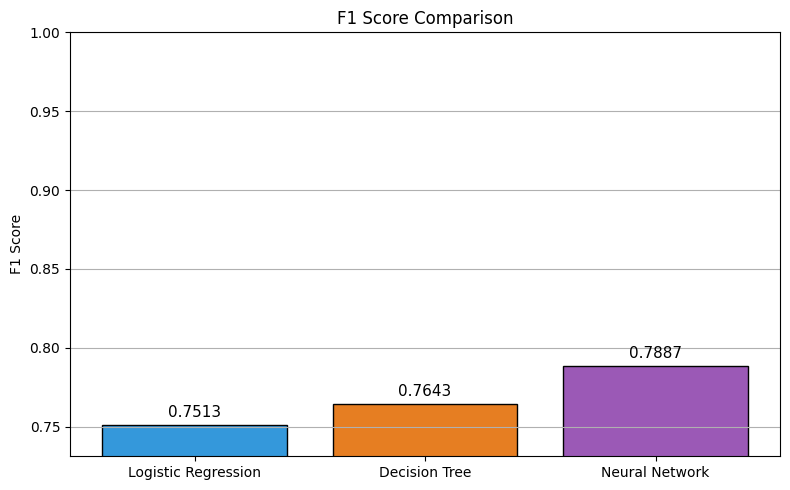

In [ ]:
# F1 Score
plt.figure(figsize=(8, 5))
bars = plt.bar(models, f1_scores,
               color=['#3498DB', '#E67E22', '#9B59B6'],
               edgecolor='black')
for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=11)
plt.title('F1 Score Comparison')
plt.ylabel('F1 Score')
plt.ylim(min(f1_scores) - 0.02, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150)
plt.show()

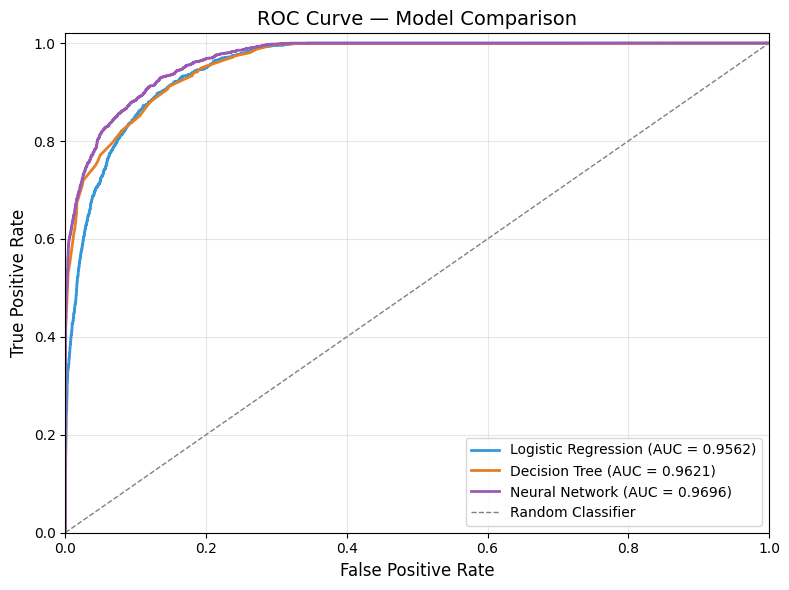

In [ ]:
# ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='#3498DB', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_dt, tpr_dt, color='#E67E22', lw=2, label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot(fpr_nn, tpr_nn, color='#9B59B6', lw=2, label=f'Neural Network (AUC = {auc_nn:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Model Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [ ]:
# Summary Table
results_df = pd.DataFrame({
    'Model':     models,
    'Accuracy':  [f'{a:.4f}' for a in accuracies],
    'Precision': [f'{p:.4f}' for p in precisions],
    'Recall':    [f'{r:.4f}' for r in recalls],
    'F1 Score':  [f'{f:.4f}' for f in f1_scores],
    'AUC':       [f'{a:.4f}' for a in auc_scores]
})
print("\nModel Comparison Summary:")
display(results_df)


Model Comparison Summary:


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8657,0.6382,0.9130,0.7513,0.9562
1,Decision Tree,0.8793,0.6752,0.8805,0.7643,0.9621
2,Neural Network,0.8940,0.7080,0.8900,0.7887,0.9696
